<a href="https://colab.research.google.com/github/souarenar/previsions-conso-electrique/blob/main/analyse_conso_electrique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
url = "https://odre.opendatasoft.com/api/explore/v2.1/catalog/datasets/eco2mix-national-tr/exports/csv?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B"
df = pd.read_csv(url, sep=";")
df.head()

,Périmètre,Nature,Date,Heure,Date - Heure,Consommation (MW),Prévision J-1 (MW),Prévision J (MW),Fioul (MW),Charbon (MW),...,Gaz - CCG (MW),Gaz - Autres (MW),Hydraulique - Fil de l'eau + éclusée (MW),Hydraulique - Lacs (MW),Hydraulique - STEP turbinage (MW),Bioénergies - Déchets (MW),Bioénergies - Biomasse (MW),Bioénergies - Biogaz (MW),Stockage batterie (MW),Déstockage batterie (MW)
0,France,Données temps réel,2026-07-01,00:00,2026-07-01T00:00:00+02:00,46807.0,47000,47000.0,35.0,0.0,...,4783.0,0.0,3614.0,2255.0,2100.0,398.0,318.0,301.0,-236.0,8.0
1,France,Données temps réel,2026-07-01,00:15,2026-07-01T00:15:00+02:00,46358.0,46100,46100.0,36.0,0.0,...,4438.0,0.0,3730.0,1955.0,2124.0,399.0,320.0,301.0,-21.0,9.0
2,France,Données temps réel,2026-07-01,00:30,2026-07-01T00:30:00+02:00,45014.0,45200,45200.0,36.0,0.0,...,4054.0,0.0,3687.0,1887.0,1321.0,401.0,319.0,301.0,-19.0,8.0
3,France,Données temps réel,2026-07-01,00:45,2026-07-01T00:45:00+02:00,43599.0,44200,44200.0,36.0,0.0,...,3846.0,0.0,3664.0,1489.0,897.0,399.0,319.0,301.0,-22.0,8.0
4,France,Données temps réel,2026-07-01,01:00,2026-07-01T01:00:00+02:00,43059.0,43200,43200.0,36.0,0.0,...,3668.0,0.0,3739.0,1431.0,814.0,398.0,319.0,301.0,-62.0,8.0


<Axes: title={'center': 'Consommation électrique nationale'}, xlabel='Date - Heure'>

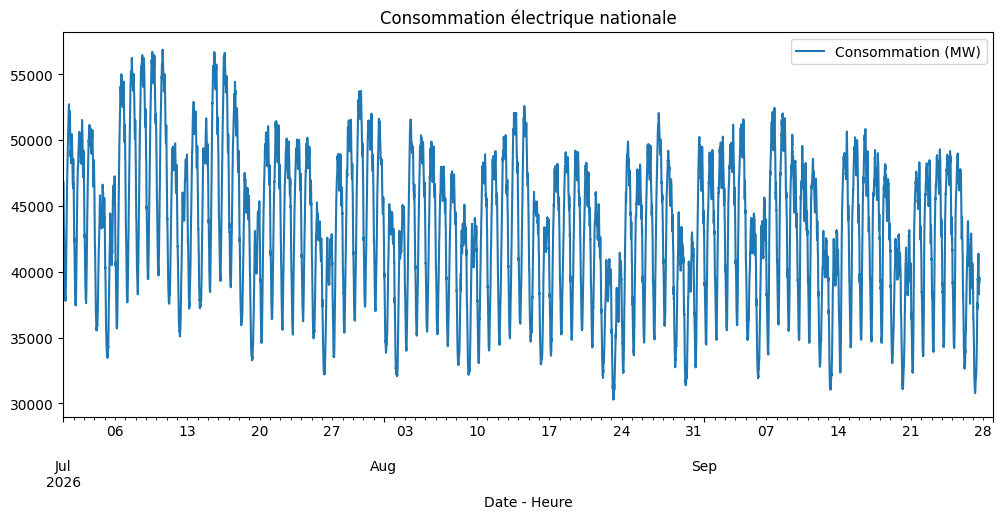

In [3]:
df["Date - Heure"] = pd.to_datetime(df["Date - Heure"])
df = df.sort_values("Date - Heure")
df.plot(x="Date - Heure", y="Consommation (MW)", figsize=(12,5), title="Consommation électrique nationale")

In [5]:
data = df.set_index("Date - Heure")["Consommation (MW)"].asfreq("15min")
data = data.interpolate()

n_test = 96 * 3
train, test = data[:-n_test], data[-n_test:]
print(len(train), len(test))

8352 288


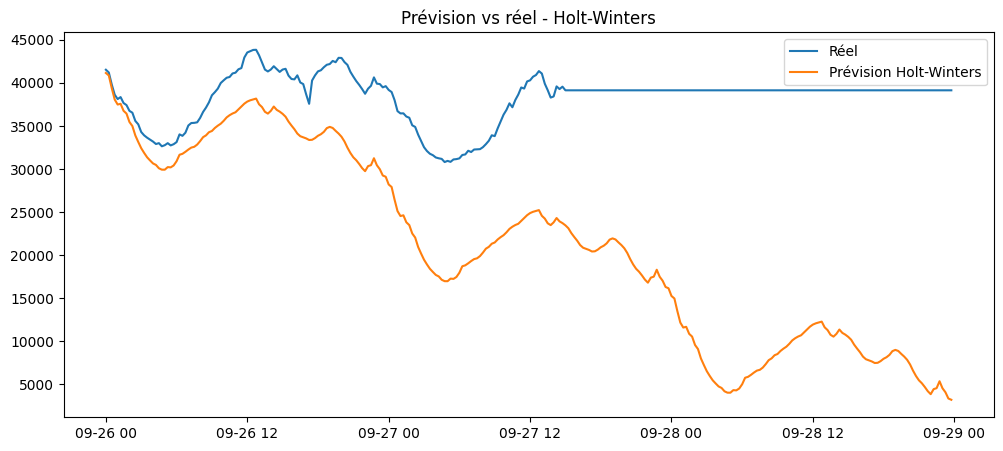

In [6]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_hw = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=96).fit()
pred_hw = model_hw.forecast(len(test))

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(test.index, test.values, label="Réel")
plt.plot(test.index, pred_hw.values, label="Prévision Holt-Winters")
plt.legend()
plt.title("Prévision vs réel - Holt-Winters")
plt.show()

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_hw = mean_absolute_error(test, pred_hw)
rmse_hw = np.sqrt(mean_squared_error(test, pred_hw))
print(f"Holt-Winters — MAE: {mae_hw:.0f} MW, RMSE: {rmse_hw:.0f} MW")

Holt-Winters — MAE: 17230 MW, RMSE: 20491 MW


In [8]:
from sklearn.ensemble import RandomForestRegressor

def make_features(series):
    d = pd.DataFrame({"y": series})
    d["hour"] = d.index.hour
    d["dayofweek"] = d.index.dayofweek
    d["lag_1"] = d["y"].shift(1)
    d["lag_96"] = d["y"].shift(96)      # même heure, veille
    d["lag_672"] = d["y"].shift(672)    # même heure, semaine précédente
    return d.dropna()

feat = make_features(data)
X = feat.drop(columns="y")
y = feat["y"]

X_train, X_test = X[:-n_test], X[-n_test:]
y_train, y_test = y[:-n_test], y[-n_test:]

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
print(f"Random Forest — MAE: {mae_rf:.0f} MW, RMSE: {rmse_rf:.0f} MW")

Random Forest — MAE: 341 MW, RMSE: 458 MW


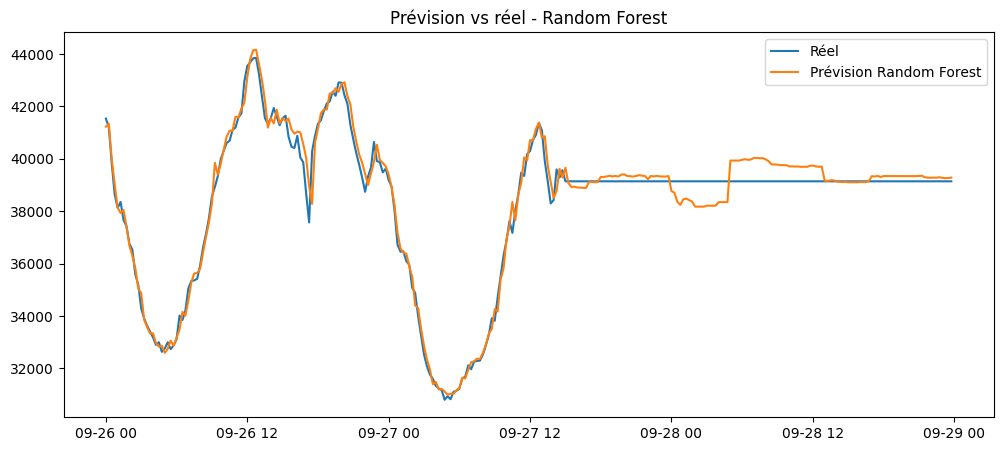

In [9]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test.values, label="Réel")
plt.plot(y_test.index, pred_rf, label="Prévision Random Forest")
plt.legend()
plt.title("Prévision vs réel - Random Forest")
plt.show()